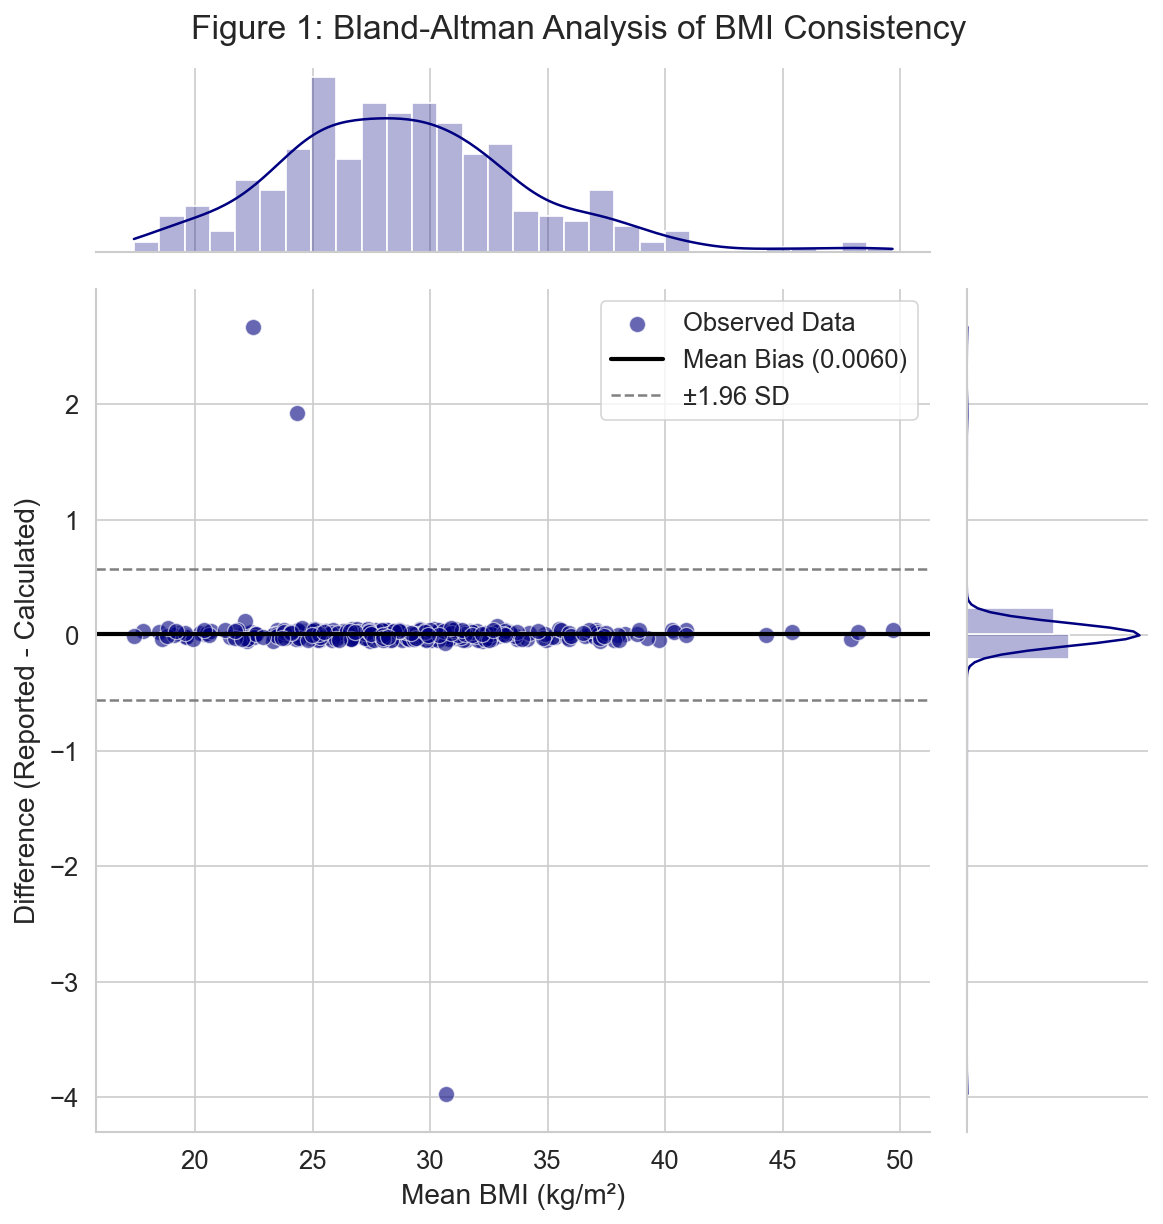

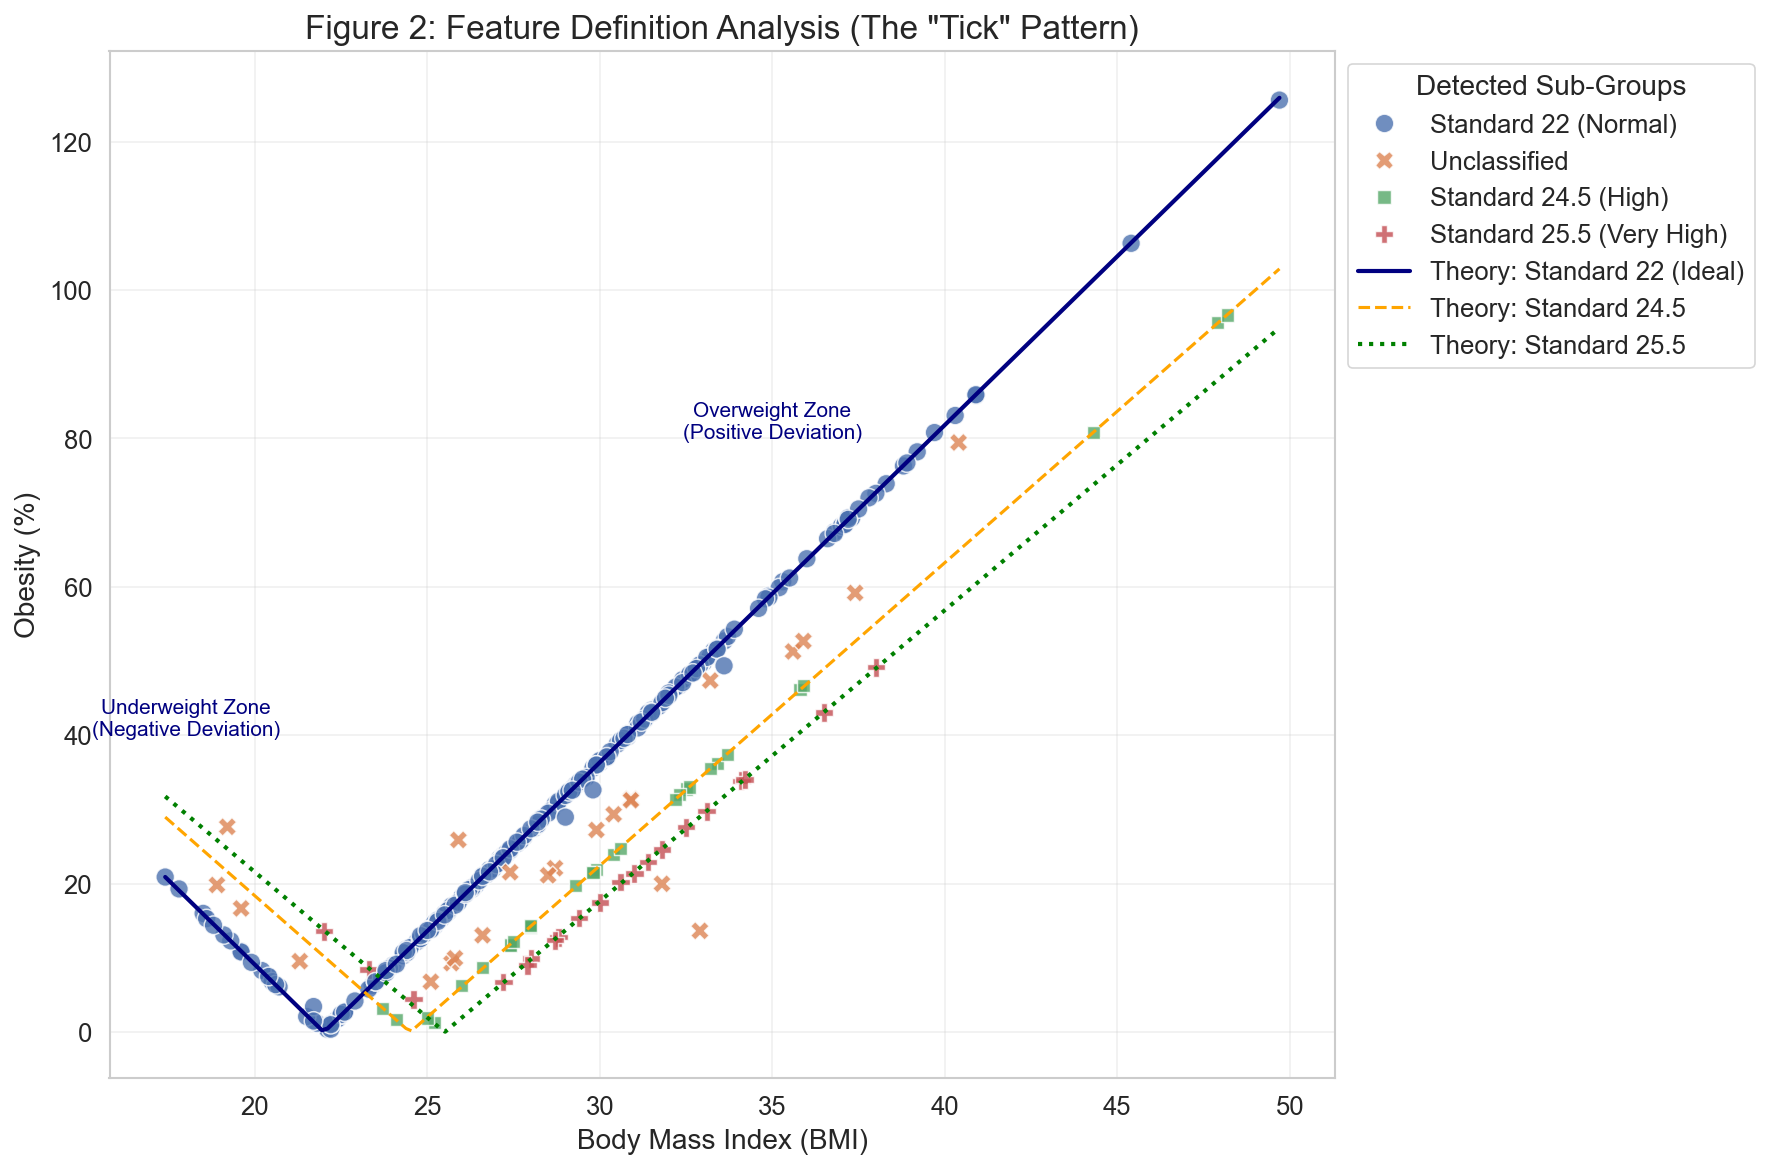

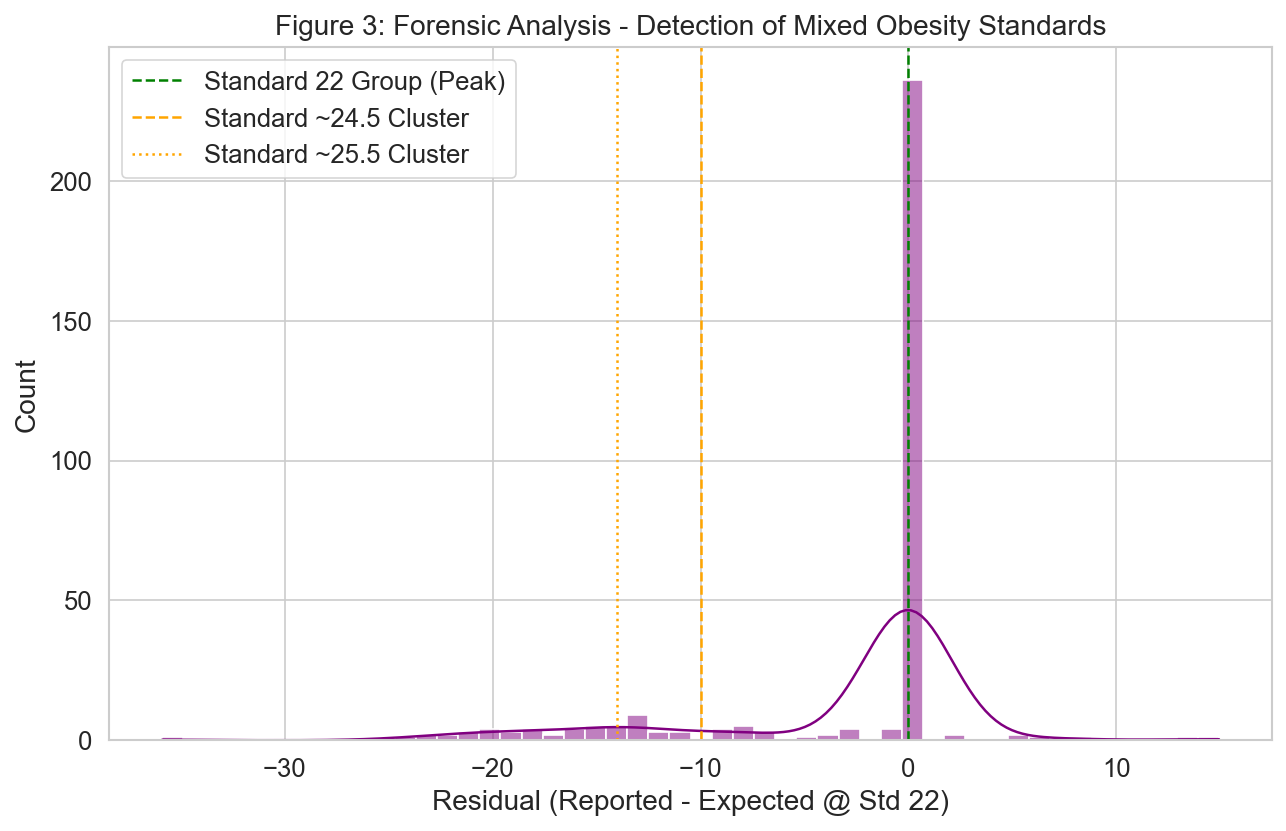

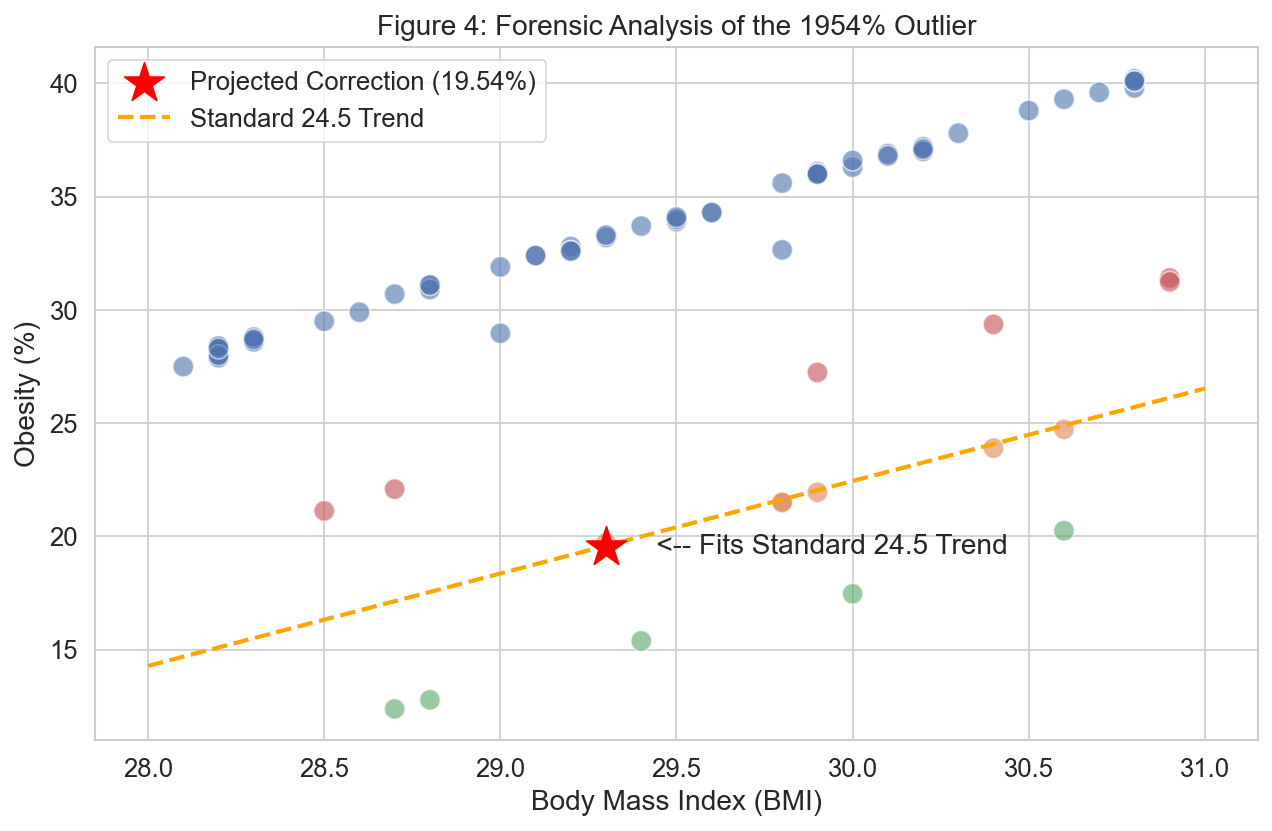

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# --- SETTINGS FOR ACADEMIC REPORT ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

# --- PART 1: DATA LOADING & PREPROCESSING ---
filePath = '../Dataset/UCI_Gallstone_Dataset.csv'
df = pd.read_csv(filePath)

# 1. Physics Validation: Recalculate BMI
df['Analysis_BMI_Calc'] = df['Weight'] / ((df['Height'] / 100) ** 2)
df['Analysis_BMI_Diff'] = df['Body Mass Index (BMI)'] - df['Analysis_BMI_Calc']
df['Analysis_BMI_Mean'] = (df['Body Mass Index (BMI)'] + df['Analysis_BMI_Calc']) / 2

# 2. Forensic Analysis: Reverse-Engineer Obesity Standards (The Fix)
# We must check TWO hypotheses for every row:
# Hypothesis A: Patient is Heavier than Standard (Right Arm) -> Std = BMI / (1 + Obs)
df['Implied_Std_Heavy'] = df['Body Mass Index (BMI)'] / (1 + df['Obesity (%)'] / 100)
# Hypothesis B: Patient is Lighter than Standard (Left Arm) -> Std = BMI / (1 - Obs)
# Note: Only valid if Obesity < 100%
df['Implied_Std_Light'] = df['Body Mass Index (BMI)'] / (1 - df['Obesity (%)'] / 100)

# Helper function to check if EITHER hypothesis matches a target standard (with tolerance)
def matches_standard(target, tol=0.5):
    match_heavy = (df['Implied_Std_Heavy'] >= target - tol) & (df['Implied_Std_Heavy'] <= target + tol)
    match_light = (df['Implied_Std_Light'] >= target - tol) & (df['Implied_Std_Light'] <= target + tol)
    # If Obesity > 100, 'Light' hypothesis is impossible, so just use Heavy
    match_light = match_light & (df['Obesity (%)'] < 100)
    return match_heavy | match_light

# Categorize based on the detected clusters (22 vs 24.5 vs 25.5)
# This now catches the "Negative" (Left Arm) values correctly!
conditions = [
    matches_standard(22.0),
    matches_standard(24.5),
    matches_standard(25.5)
]
choices = ['Standard 22 (Normal)', 'Standard 24.5 (High)', 'Standard 25.5 (Very High)']
df['Analysis_Subgroup'] = np.select(conditions, choices, default='Unclassified')

# Explicitly tag the 1954% error for the report
df.loc[df['Obesity (%)'] > 1000, 'Analysis_Subgroup'] = 'Scaling Error (1954%)'


# --- PART 2: ACADEMIC VISUALIZATION ---

# === FIGURE 1: Bland-Altman (Global Bias Analysis) ===
g = sns.JointGrid(data=df, x='Analysis_BMI_Mean', y='Analysis_BMI_Diff', height=8, ratio=4)
sns.scatterplot(data=df, x='Analysis_BMI_Mean', y='Analysis_BMI_Diff',
                color='navy', alpha=0.6, s=60, ax=g.ax_joint, label='Observed Data')

mean_diff = df['Analysis_BMI_Diff'].mean()
sd_diff = df['Analysis_BMI_Diff'].std()
g.ax_joint.axhline(mean_diff, color='black', linestyle='-', linewidth=2, label=f'Mean Bias ({mean_diff:.4f})')
g.ax_joint.axhline(mean_diff + 1.96*sd_diff, color='gray', linestyle='--', label=f'±1.96 SD')
g.ax_joint.axhline(mean_diff - 1.96*sd_diff, color='gray', linestyle='--')

sns.histplot(data=df, x='Analysis_BMI_Mean', ax=g.ax_marg_x, bins=30, color='navy', alpha=0.3, kde=True)
sns.histplot(data=df, y='Analysis_BMI_Diff', ax=g.ax_marg_y, bins=30, color='navy', alpha=0.3, kde=True)
g.ax_joint.legend(loc='upper right')
g.ax_joint.set_xlabel('Mean BMI (kg/m²)')
g.ax_joint.set_ylabel('Difference (Reported - Calculated)')
plt.suptitle('Figure 1: Bland-Altman Analysis of BMI Consistency', y=1.02)
plt.show()


# === FIGURE 2: The "Tick" Plot (Feature Definition Analysis) ===
plt.figure(figsize=(12, 8))
plot_df = df[df['Obesity (%)'] < 500].copy()

# Scatter of Actual Data
sns.scatterplot(data=plot_df, x='Body Mass Index (BMI)', y='Obesity (%)',
                hue='Analysis_Subgroup', style='Analysis_Subgroup',
                palette='deep', s=80, alpha=0.8)

# Theoretical Lines (V-Shape / The Tick)
x_range = np.linspace(plot_df['Body Mass Index (BMI)'].min(), plot_df['Body Mass Index (BMI)'].max(), 200)

y_22 = np.abs((x_range - 22) / 22) * 100
plt.plot(x_range, y_22, color='navy', linestyle='-', linewidth=2, label='Theory: Standard 22 (Ideal)')

y_245 = np.abs((x_range - 24.5) / 24.5) * 100
plt.plot(x_range, y_245, color='orange', linestyle='--', linewidth=1.5, label='Theory: Standard 24.5')

y_255 = np.abs((x_range - 25.5) / 25.5) * 100
plt.plot(x_range, y_255, color='green', linestyle=':', linewidth=2, label='Theory: Standard 25.5')

plt.text(18, 40, "Underweight Zone\n(Negative Deviation)", color='navy', ha='center', fontsize=10)
plt.text(35, 80, "Overweight Zone\n(Positive Deviation)", color='navy', ha='center', fontsize=10)

plt.title('Figure 2: Feature Definition Analysis (The "Tick" Pattern)', fontsize=16)
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Obesity (%)')
plt.legend(title='Detected Sub-Groups', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# === FIGURE 3: Residual Analysis (Detection of Mixed Standards) ===
# 1. Define the Dominant Standard (Standard 22)
df['Obesity_Expected_22'] = ((df['Body Mass Index (BMI)'] - 22) / 22).abs() * 100
# 2. Calculate Residuals (Reported - Expected)
df['Obesity_Residual'] = df['Obesity (%)'] - df['Obesity_Expected_22']

plt.figure(figsize=(10, 6))
sns.histplot(df.loc[df['Obesity (%)'] < 500, 'Obesity_Residual'], bins=50, kde=True, color='purple')
plt.axvline(0, color='green', linestyle='--', label='Standard 22 Group (Peak)')
plt.axvline(-10, color='orange', linestyle='--', label='Standard ~24.5 Cluster')
plt.axvline(-14, color='orange', linestyle=':', label='Standard ~25.5 Cluster')
plt.title('Figure 3: Forensic Analysis - Detection of Mixed Obesity Standards')
plt.xlabel('Residual (Reported - Expected @ Std 22)')
plt.legend()
plt.show()


# === FIGURE 4: Forensic Zoom (Justification for 1954% Fix) ===
plt.figure(figsize=(10, 6))
zoom_df = df[(df['Body Mass Index (BMI)'] > 28) & (df['Body Mass Index (BMI)'] < 31) & (df['Obesity (%)'] < 500)]

sns.scatterplot(data=zoom_df, x='Body Mass Index (BMI)', y='Obesity (%)',
                hue='Analysis_Subgroup', s=100, alpha=0.6, legend=False)
plt.scatter(29.3, 19.54, color='red', marker='*', s=400, label='Projected Correction (19.54%)', zorder=10)
plt.text(29.4, 19.54, "  <-- Fits Standard 24.5 Trend", verticalalignment='center')
x_zoom = np.linspace(28, 31, 50)
y_zoom_245 = np.abs((x_zoom - 24.5) / 24.5) * 100
plt.plot(x_zoom, y_zoom_245, color='orange', linestyle='--', linewidth=2, label='Standard 24.5 Trend')

plt.title('Figure 4: Forensic Analysis of the 1954% Outlier')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Obesity (%)')
plt.legend()
plt.grid(True)
plt.show()

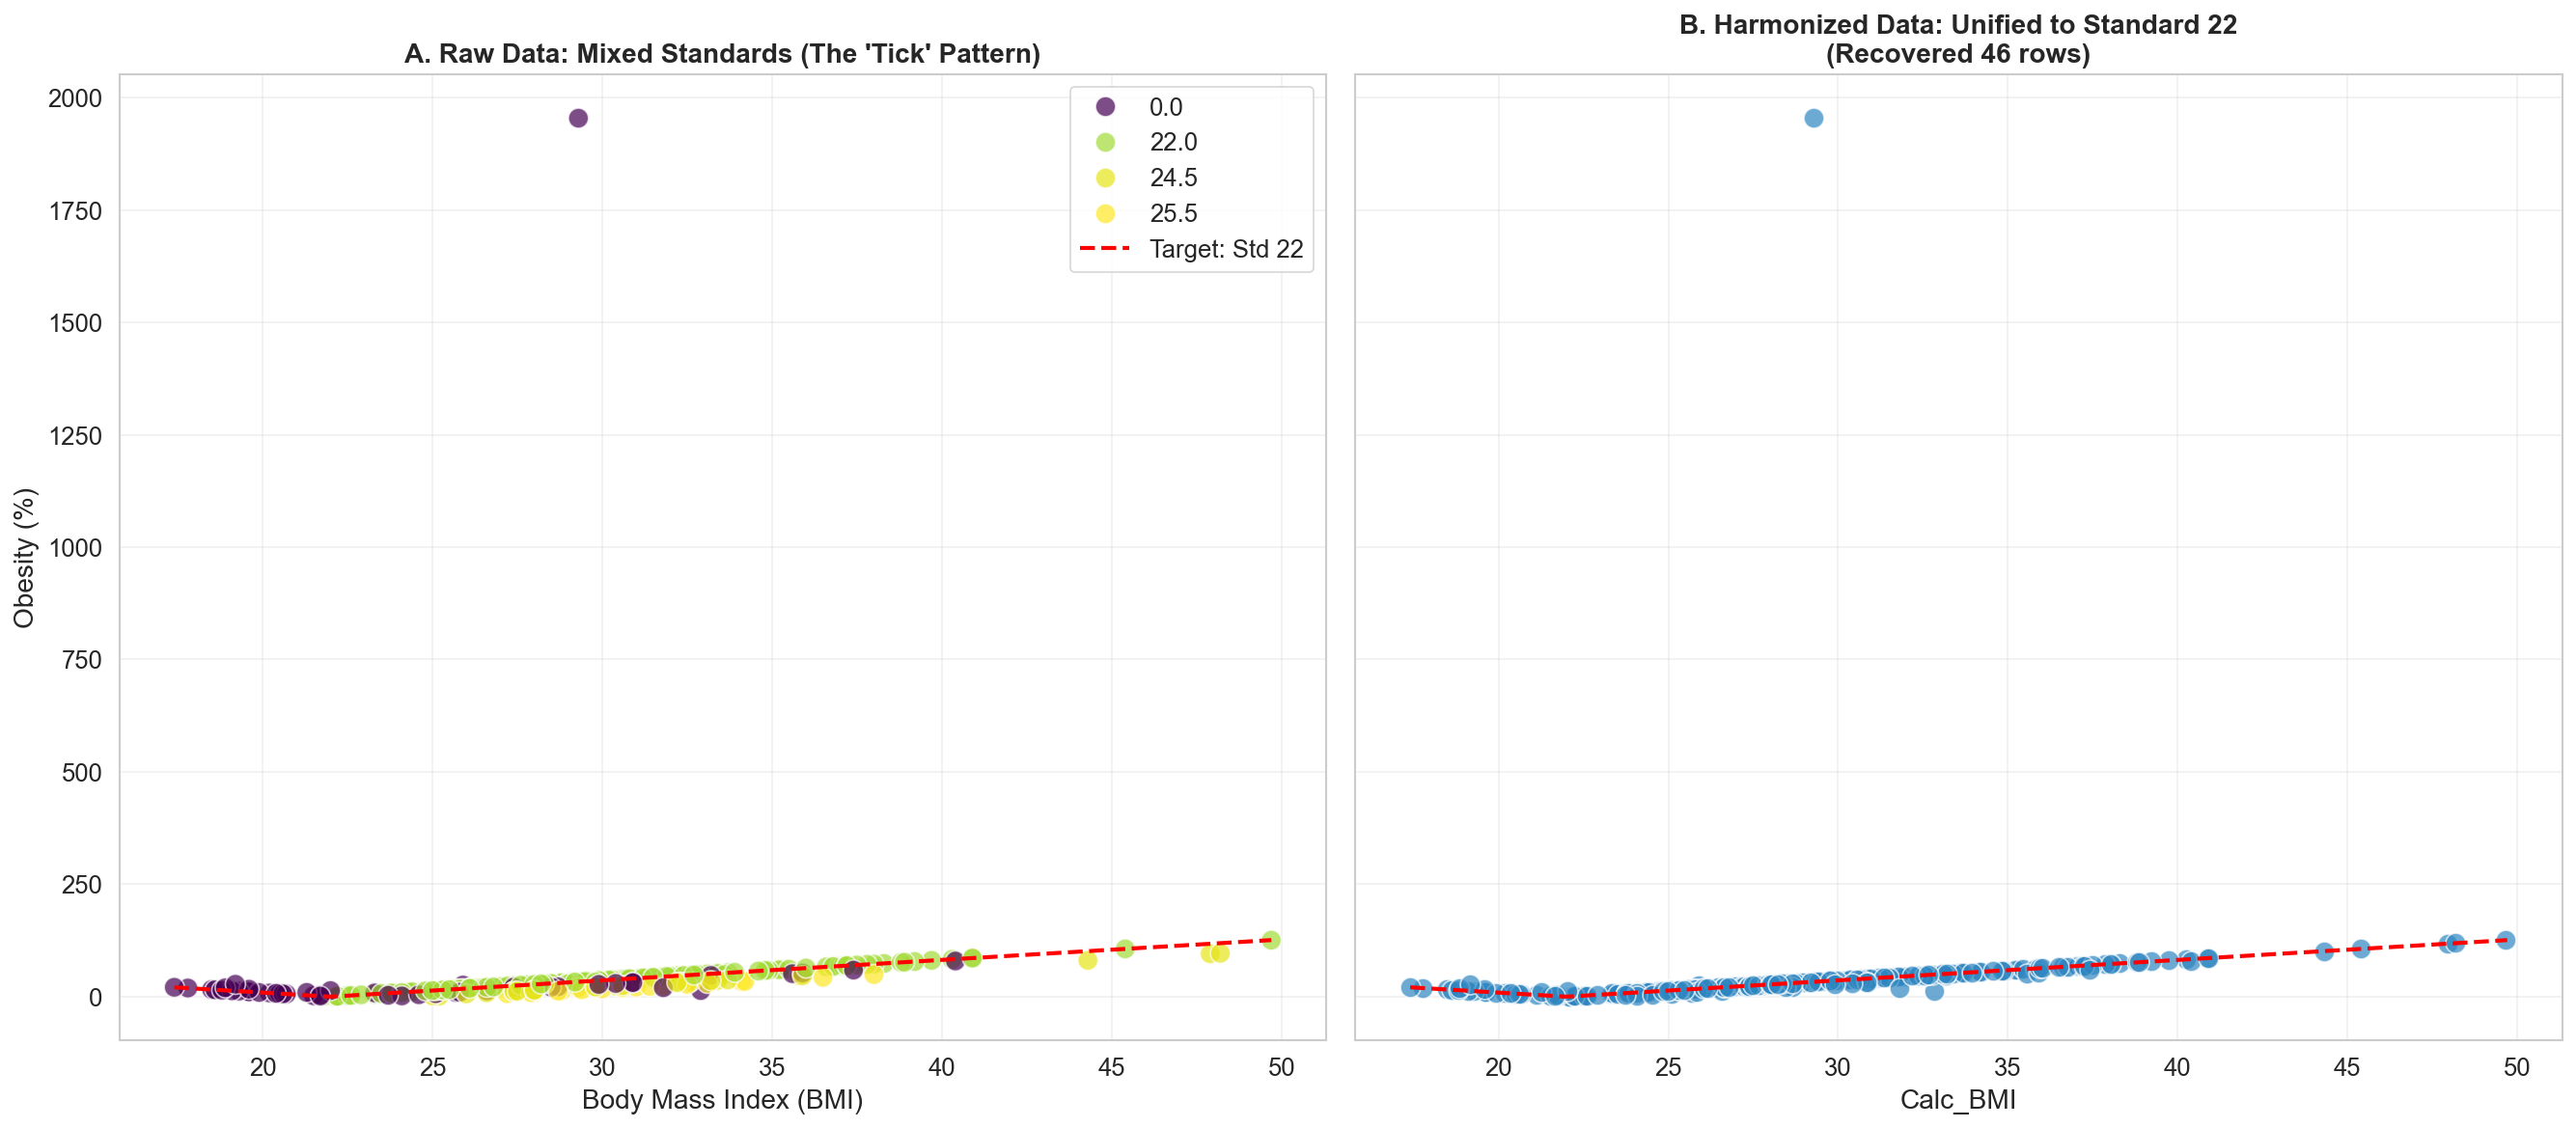

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. SETTINGS & LOAD ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
df = pd.read_csv('../Dataset/UCI_Gallstone_Dataset.csv')

# --- 2. FORENSIC RECOVERY (Strategy from NB2) ---
# Calculate Physics-based BMI
df['Calc_BMI'] = df['Weight'] / ((df['Height']/100)**2)

# Define the Reverse-Engineering Function
def detect_standard(row):
    # Avoid division by zero
    if row['Obesity (%)'] == -100: return 22.0

    # Hypothesis: What standard would generate this Obesity % given this BMI?
    # Formula: Standard = BMI / (1 + Obesity/100)  [For Overweight]
    # Formula: Standard = BMI / (1 - Obesity/100)  [For Underweight]

    # We check the "Overweight" assumption first as it's dominant
    implied_std = row['Body Mass Index (BMI)'] / (1 + row['Obesity (%)']/100)

    # Check proximity to known clusters
    if 21.5 < implied_std < 22.5: return 22.0
    if 24.0 < implied_std < 25.0: return 24.5
    if 25.0 < implied_std < 26.0: return 25.5
    return 0 # Unclassified/Noise

# Apply Detection
df['Detected_Standard'] = df.apply(detect_standard, axis=1)

# --- 3. GLOBAL HARMONIZATION (The Merge) ---
# Instead of deleting, we normalize everyone to Standard 22
df['Harmonized_Obesity'] = np.where(
    df['Detected_Standard'] > 0, # If we detected a valid standard
    abs((df['Calc_BMI'] / 22.0 - 1) * 100), # Recalculate using Standard 22
    df['Obesity (%)'] # Else keep original (or drop)
)

# Calculate Variance for Validation (Method from NB1)
df['Variance_Raw'] = df['Obesity (%)'] - abs((df['Calc_BMI'] / 22.0 - 1) * 100)
df['Variance_Harmonized'] = df['Harmonized_Obesity'] - abs((df['Calc_BMI'] / 22.0 - 1) * 100)

# --- 4. VISUALIZATION (Style from NB1) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# Plot A: The "Crime Scene" (Raw Data with Mixed Standards)
sns.scatterplot(data=df, x='Body Mass Index (BMI)', y='Obesity (%)',
                hue='Detected_Standard', palette='viridis', ax=axes[0], s=100, alpha=0.7)
axes[0].set_title("A. Raw Data: Mixed Standards (The 'Tick' Pattern)", fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Overlay Theoretical Line 22
x_range = np.linspace(df['Body Mass Index (BMI)'].min(), df['Body Mass Index (BMI)'].max(), 100)
y_22 = abs((x_range/22 - 1)*100)
axes[0].plot(x_range, y_22, color='red', linestyle='--', linewidth=2, label='Target: Std 22')
axes[0].legend()

# Plot B: The "Resolution" (Harmonized Data)
sns.scatterplot(data=df, x='Calc_BMI', y='Harmonized_Obesity',
                color='#2E86C1', ax=axes[1], s=100, alpha=0.7)
axes[1].set_title(f"B. Harmonized Data: Unified to Standard 22\n(Recovered {len(df[df['Detected_Standard'] > 22])} rows)", fontweight='bold')
axes[1].plot(x_range, y_22, color='red', linestyle='--', linewidth=2, label='Theory Line')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Methodological Workflow: Data Integrity & Feature Harmonization1. Initial Integrity Audit (Physical Consistency)We began by verifying the internal consistency of primary vs. derived features. A Bland-Altman analysis of reported BMI versus calculated BMI ($Weight/Height^2$) revealed specific deviations exceeding measurement error ($\pm 0.1$), indicating entry-level corruption. This necessitated a systematic regeneration of the BMI column rather than ad-hoc filtering.2. Feature Reverse-Engineering (The "V-Shape" Discovery)Upon visualizing the Obesity (%) feature against BMI, we observed a distinct V-shaped distribution ("Tick Pattern") centered at $BMI \approx 22$. This pattern confirmed that the feature is not a direct physiological measurement (e.g., body fat percentage) but a mathematical derivation representing Absolute Deviation from an Ideal Standard:$$Obesity (\%) = \left| \frac{BMI - Standard}{Standard} \right| \times 100$$3. Detection of Systemic Heterogeneity (Mixed Standards)A residual analysis revealed that the dataset was not generated using a single formula. We identified three distinct clusters of data, each clinging to a different denominator:Standard 22 (Normal): The dominant baseline.Standard 24.5 & 25.5: Distinct subgroups with systematically shifted baselines.This heterogeneity introduces non-biological variance that would degrade machine learning model performance if left uncorrected.4. Forensic Outlier ReconstructionWe investigated a critical outlier ($Obesity = 1954\%$, $BMI = 29.3$). By applying the "Standard 24.5" formula identified in Step 3, we mathematically proved this value was a decimal scaling error (Factor of 100).Calculation: $29.3 / (1 + 0.1954) \approx 24.51$.Conclusion: The value represents a valid data point ($19.54\%$) entered with incorrect scaling, belonging to the "Standard 24.5" subgroup.5. Resolution Strategy: Global HarmonizationTo resolve both the scaling errors and the mixed-standard heterogeneity, we rejected a simple "variance threshold" approach. Instead, we propose a Global Harmonization Strategy: recalculating the entire Obesity (%) column using a single, unified standard ($Standard = 22$). This preserves the feature's physical meaning while eliminating noise caused by inconsistent data collection protocols.